## Definizione dei dettagli del progetto [Step 0]

- Predictive analytics
- Target scelto: Produzione lorda totale, perché è la colonna più lunga e continua della tabella, disponibile dal 1883.
- La serie ha frequenza annuale, quindi non presenta una stagionalità intra-annuale come una serie mensile o trimestrale. Di conseguenza, il primo candidato statistico naturale è un ARIMA non stagionale.
- L’approccio è time series univariato, perché le altre colonne non sono veri driver esogeni indipendenti, ma componenti o ripartizioni del fenomeno totale.
- L’obiettivo è fare previsioni di medio-lungo termine.
- Le rotture strutturali sono presenti e vanno riconosciute nell’analisi, ma in questa prima fase non vengono trattate esplicitamente con modelli dedicati: si mantiene la serie completa e si verifica se il modello riesce comunque a descriverne la dinamica.

## Preparazione e comprensione del dataset [Step 1]

In questo step non stimiamo ancora modelli. L'obiettivo e' costruire una base dati pulita e capire la struttura della serie prima del preprocessing.

Cosa facciamo:
- carichiamo il file grezzo;
- estraiamo la variabile target scelta nello Step 0: Produzione lorda totale;
- convertiamo anno e valori in formato numerico;
- controlliamo missing values, dimensione e statistiche descrittive;
- visualizziamo andamento temporale, distribuzione e possibili rotture strutturali.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("Datasets") / "Tavola_1.14.csv"
TARGET_COL = "Produzione_lorda_totale"

In [2]:
raw_preview = pd.read_csv(DATA_PATH, sep=";", header=None, dtype=str)
raw_preview.head(8)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,ANNI,Produzione lorda (a),NaN,NaN,NaN,Consumo,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Totale,Di cui,NaN,NaN,Agricol-tura,Industria,NaN,Trasporti,Illumina-\nzione pubblica,"Commercio, servizi, pubblica ammi...",Usi domestici,Totale
2,NaN,NaN,Termo-elettrica tradizio-\nnale (b),Geo- termo-elettrica,NaN,NaN,Totale,di cui Manufat-turiera,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1883,1,....,-,NaN,....,....,....,....,....,....,....,....
5,1884,2,....,-,NaN,....,....,....,....,....,....,....,....
6,1885,3,....,-,NaN,....,....,....,....,....,....,....,....
7,1886,3,....,-,NaN,....,....,....,....,....,....,....,....


In [3]:
series_df = pd.read_csv(
    DATA_PATH,
    sep=";",
    skiprows=4,
    header=None,
    usecols=[0, 1],
    names=["Anno", TARGET_COL],
    dtype=str,
    encoding="utf-8",
)

series_df["Anno"] = series_df["Anno"].str.extract(r"(\d{4})").astype(int)
series_df[TARGET_COL] = (
    series_df[TARGET_COL]
    .str.strip()
    .replace({"....": pd.NA, "-": pd.NA, "": pd.NA})
    .str.replace(".", "", regex=False)
    .astype("Float64")
)

series_df = series_df.sort_values("Anno").set_index("Anno")
series_df.index = pd.Index(series_df.index, name="Anno")

series_df.head()

,Produzione_lorda_totale
Anno,
1883,1.0
1884,2.0
1885,3.0
1886,3.0
1887,4.0


In [4]:
summary = series_df[TARGET_COL].describe().to_frame(name="value")
summary.loc["missing_values"] = series_df[TARGET_COL].isna().sum()
summary.loc["start_year"] = series_df.index.min()
summary.loc["end_year"] = series_df.index.max()
summary.loc["n_observations"] = len(series_df)
summary

,value
count,132.0
mean,89862.825758
std,107574.541777
min,1.0
25%,3300.0
50%,21738.0
75%,182721.75
max,319130.0
missing_values,0.0
start_year,1883.0


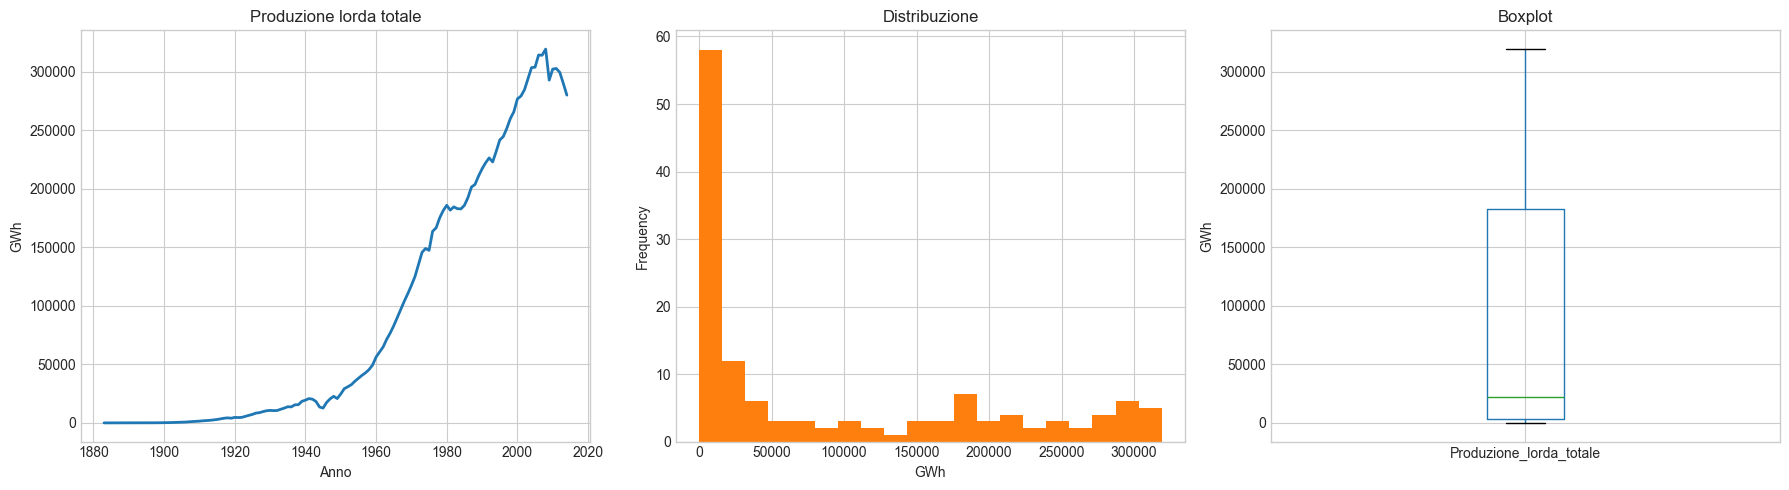

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

series_df[TARGET_COL].plot(ax=axes[0], color="tab:blue", lw=2, title="Produzione lorda totale")
axes[0].set_xlabel("Anno")
axes[0].set_ylabel("GWh")

series_df[TARGET_COL].plot(kind="hist", bins=20, ax=axes[1], color="tab:orange", title="Distribuzione")
axes[1].set_xlabel("GWh")

series_df.boxplot(column=TARGET_COL, ax=axes[2])
axes[2].set_title("Boxplot")
axes[2].set_ylabel("GWh")

plt.tight_layout()
plt.show()

### Osservazioni attese da Step 1

- La serie dovrebbe mostrare un trend crescente di lungo periodo, quindi non e' plausibilmente stazionaria in livello.
- Essendo annuale, non ci aspettiamo stagionalita' classica.
- Le rotture strutturali principali dovrebbero emergere soprattutto intorno ai periodi di guerra, crisi petrolifera e crisi del 2008.
- Il risultato di questo step non e' scegliere il modello, ma verificare che il target sia pulito, consistente e interpretabile prima del preprocessing dello Step 2.

## Preprocessing [Step 2]

In questo step verifichiamo se la serie e' stazionaria e quali trasformazioni siano piu' adatte prima della modellazione statistica.

Obiettivi:
- testare la stazionarieta' della serie in livello;
- confrontare trasformazioni candidate come log, prima differenza e seconda differenza;
- osservare la struttura di autocorrelazione tramite ACF e PACF;
- arrivare a una prima ipotesi ragionata per il preprocessing del modello ARIMA.

In [6]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

target_series = series_df[TARGET_COL].astype(float)

def adf_report(series, name):
    stat, pvalue, *_ = adfuller(series.dropna())
    return {
        "series": name,
        "adf_stat": stat,
        "pvalue": pvalue,
        "stationary_at_5pct": pvalue < 0.05,
    }

In [7]:
candidate_series = {
    "level": target_series,
    "log": np.log(target_series),
    "diff_1": target_series.diff(),
    "log_diff_1": np.log(target_series).diff(),
    "diff_2": target_series.diff().diff(),
}

adf_results = pd.DataFrame(
    [adf_report(series, name) for name, series in candidate_series.items()]
).set_index("series")

adf_results

,adf_stat,pvalue,stationary_at_5pct
series,,,
level,-1.459970,5.532128e-01,False
log,-4.759796,6.488138e-05,True
diff_1,-1.906669,3.289303e-01,False
log_diff_1,-2.681483,7.729769e-02,False
diff_2,-8.871223,1.396268e-14,True


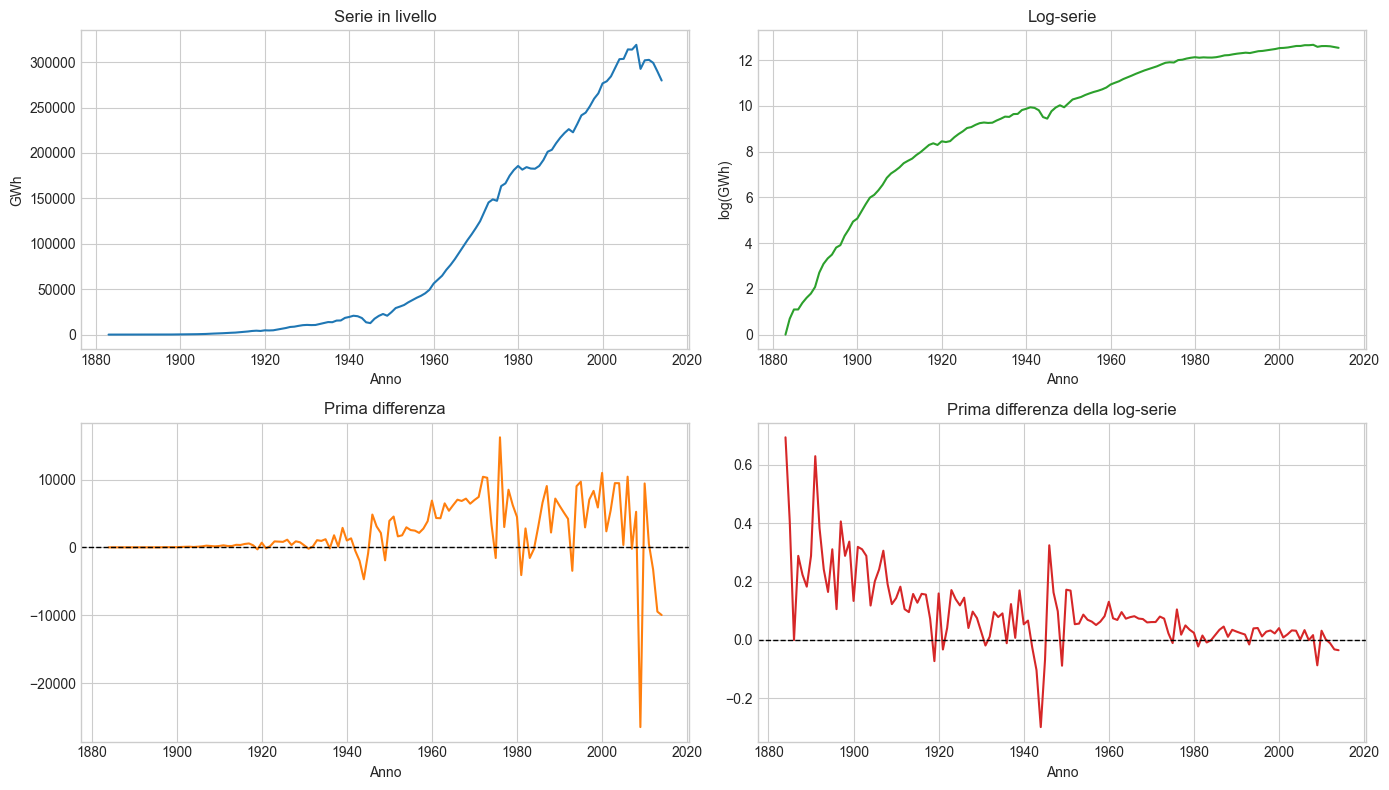

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

candidate_series["level"].plot(ax=axes[0, 0], color="tab:blue", title="Serie in livello")
axes[0, 0].set_ylabel("GWh")

candidate_series["log"].plot(ax=axes[0, 1], color="tab:green", title="Log-serie")
axes[0, 1].set_ylabel("log(GWh)")

candidate_series["diff_1"].plot(ax=axes[1, 0], color="tab:orange", title="Prima differenza")
axes[1, 0].axhline(0, color="black", lw=1, ls="--")

candidate_series["log_diff_1"].plot(ax=axes[1, 1], color="tab:red", title="Prima differenza della log-serie")
axes[1, 1].axhline(0, color="black", lw=1, ls="--")

plt.tight_layout()
plt.show()

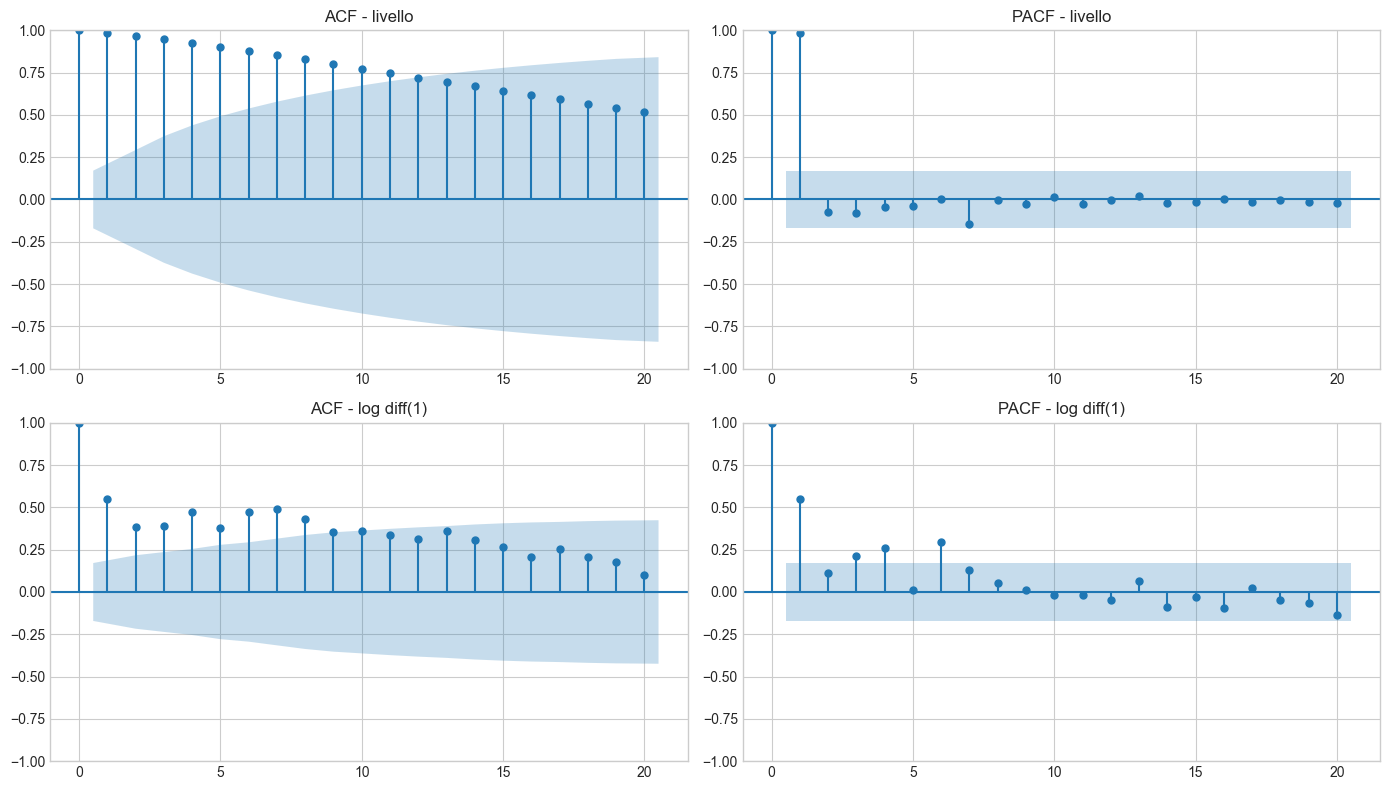

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(candidate_series["level"].dropna(), lags=20, ax=axes[0, 0])
axes[0, 0].set_title("ACF - livello")

plot_pacf(candidate_series["level"].dropna(), lags=20, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF - livello")

plot_acf(candidate_series["log_diff_1"].dropna(), lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF - log diff(1)")

plot_pacf(candidate_series["log_diff_1"].dropna(), lags=20, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF - log diff(1)")

plt.tight_layout()
plt.show()

### Lettura metodologica di Step 2

- Se la serie in livello ha p-value ADF alto, non possiamo considerarla stazionaria.
- Se la log-serie stabilizza la variabilita' ma resta non stazionaria, il trend non e' ancora stato rimosso.
- La prima differenza, soprattutto sulla log-serie, e' spesso la candidata piu' naturale per una serie economico-energetica con crescita di lungo periodo.
- Non introduciamo per ora una differenza stagionale, perche' la serie e' annuale e non ha una periodicita' intra-annuale da modellare con SARIMA.
- Dopo l'esecuzione di queste celle, lo scopo e' decidere quale trasformazione portare nello Step 3 e nello Step 4 come input del modello statistico.

### Prime conclusioni operative di Step 2

- La serie in livello non e' stazionaria: l'ADF restituisce un p-value alto e l'ACF decresce molto lentamente, comportamento tipico di una serie con trend marcato.
- La log-trasformazione comprime la scala e puo' aiutare a stabilizzare la varianza, ma da sola non basta a chiarire completamente la dinamica della serie.
- La prima differenza semplice non e' ancora sufficiente per ottenere una stazionarieta' robusta.
- La prima differenza della log-serie e' una candidata interessante, ma al 5% non supera ancora il test ADF.
- La seconda differenza e' la trasformazione che, in questa fase esplorativa, mostra il segnale piu' netto di stazionarizzazione.
- Poiche' la serie e' annuale, non emerge alcuna motivazione per introdurre una differenza stagionale.
- Prima ipotesi di lavoro per il modello statistico: partire da un ARIMA non stagionale con attenzione a d = 2, e confrontarlo eventualmente con una variante sulla log-serie nei passaggi successivi.

## Split temporale train / validation / test [Step 3]

In questo step fissiamo una suddivisione cronologica coerente con il problema di forecasting.

Scelta metodologica:
- niente shuffle, per evitare data leakage temporale;
- train abbastanza ampio da stimare un modello ARIMA su una serie annuale relativamente corta;
- validation e test abbastanza lunghi da valutare il comportamento del modello su piu' di un decennio.

Per questa serie scegliamo uno split circa 80 / 10 / 10.

In [10]:
n_obs = len(target_series)
train_end = int(n_obs * 0.80)
val_end = int(n_obs * 0.90)

train_series = target_series.iloc[:train_end].copy()
val_series = target_series.iloc[train_end:val_end].copy()
test_series = target_series.iloc[val_end:].copy()

split_summary = pd.DataFrame(
    {
        "subset": ["train", "validation", "test"],
        "n_obs": [len(train_series), len(val_series), len(test_series)],
        "start_year": [train_series.index.min(), val_series.index.min(), test_series.index.min()],
        "end_year": [train_series.index.max(), val_series.index.max(), test_series.index.max()],
    }
)

split_summary

,subset,n_obs,start_year,end_year
0,train,105,1883,1987
1,validation,13,1988,2000
2,test,14,2001,2014


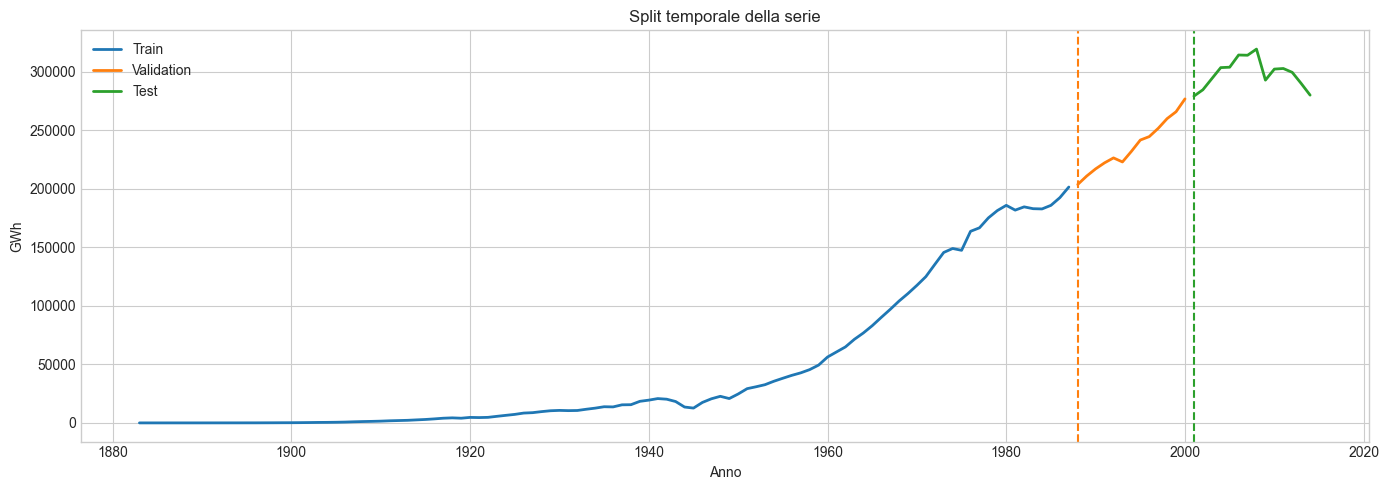

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

train_series.plot(ax=ax, label="Train", color="tab:blue", lw=2)
val_series.plot(ax=ax, label="Validation", color="tab:orange", lw=2)
test_series.plot(ax=ax, label="Test", color="tab:green", lw=2)

ax.axvline(val_series.index.min(), color="tab:orange", ls="--", lw=1.5)
ax.axvline(test_series.index.min(), color="tab:green", ls="--", lw=1.5)
ax.set_title("Split temporale della serie")
ax.set_xlabel("Anno")
ax.set_ylabel("GWh")
ax.legend()

plt.tight_layout()
plt.show()

### Conclusione di Step 3

- Lo split e' puramente cronologico e preserva la logica reale del forecasting.
- Con 132 osservazioni annuali, il train resta abbastanza ampio per la stima, mentre validation e test coprono ciascuno piu' di un decennio.
- Questa scelta consente di usare la validation per selezione e tuning del modello, lasciando il test come valutazione finale fuori campione.
- I parametri di eventuali trasformazioni successive dovranno essere stimati solo sul train e poi applicati a validation e test.